# LeetCode #109: Convert Sorted List to Binary Search Tree

https://leetcode.com/problems/convert-sorted-list-to-binary-search-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Convert list to array | O(n) | O(n) | Extra space for array, then use #108 |
| **Slow/Fast pointer (in-place) ★** | **O(n log n)** | **O(log n)** | Find mid in-place, split list, recurse |

---

## Understanding the Methods

### Brute Force (Convert to Array)
Copy all list values to an array. Then apply the same divide-and-conquer as #108. Simple but uses O(n) extra space.

### Slow/Fast Pointer (Optimal for Space ★)
Use slow/fast pointer to find middle node. Track `prev` to disconnect the left half (`prev.next = null`). Build root from `slow`. Recurse on the two halves. O(n log n) time but only O(log n) stack space.

## Constraints
- List length: [0, 2×10⁴]
- Node values: [-10⁵, 10⁵]
- Guaranteed sorted in ascending order

## Solutions

### C#

In [ ]:
public class Solution {
    public TreeNode SortedListToBST(ListNode head) {
        if (head == null)       return null;
        if (head.next == null)  return new TreeNode(head.val);

        ListNode prev = null, slow = head, fast = head;
        while (fast != null && fast.next != null) {
            prev = slow;
            slow = slow.next;
            fast = fast.next.next;
        }
        prev.next = null;  // cut left half

        var node    = new TreeNode(slow.val);
        node.left   = SortedListToBST(head);
        node.right  = SortedListToBST(slow.next);
        return node;
    }
}

### Python

In [ ]:
class Solution:
    def sortedListToBST(self, head):
        if not head:            return None
        if not head.next:       return TreeNode(head.val)

        prev, slow, fast = None, head, head
        while fast and fast.next:
            prev = slow
            slow = slow.next
            fast = fast.next.next
        prev.next = None  # cut

        node       = TreeNode(slow.val)
        node.left  = self.sortedListToBST(head)
        node.right = self.sortedListToBST(slow.next)
        return node

### Go

In [ ]:
func sortedListToBST(head *ListNode) *TreeNode {
    if head == nil       { return nil }
    if head.Next == nil  { return &TreeNode{Val: head.Val} }

    var prev *ListNode
    slow, fast := head, head
    for fast != nil && fast.Next != nil {
        prev = slow
        slow = slow.Next
        fast = fast.Next.Next
    }
    prev.Next = nil  // cut

    node        := &TreeNode{Val: slow.Val}
    node.Left    = sortedListToBST(head)
    node.Right   = sortedListToBST(slow.Next)
    return node
}

### Rust

In [ ]:
// Rust: convert to vec for simplicity (slow/fast on Box<ListNode> is complex)
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn sorted_list_to_bst(head: Option<Box<ListNode>>) -> Option<Rc<RefCell<TreeNode>>> {
        let mut vals = vec![];
        let mut cur  = head.as_ref();
        while let Some(node) = cur {
            vals.push(node.val);
            cur = node.next.as_ref();
        }

        fn build(vals: &[i32]) -> Option<Rc<RefCell<TreeNode>>> {
            if vals.is_empty() { return None; }
            let mid  = vals.len() / 2;
            let node = Rc::new(RefCell::new(TreeNode::new(vals[mid])));
            node.borrow_mut().left  = build(&vals[..mid]);
            node.borrow_mut().right = build(&vals[mid+1..]);
            Some(node)
        }
        build(&vals)
    }
}

## Example Scenarios

### 1. Common Case — 5-Node Sorted List
**Input:** `head = [-10, -3, 0, 5, 9]`

Slow/fast pointer: fast reaches end when slow is at 0 (index 2). Cut: prev(-3).next = null. Root = 0. Left list: [-10, -3]. Right list: [5, 9]. Same result as #108.

*Why tricky:* Baseline. Slow/fast finds middle in $O(n)$ without random access. Unlike #108, we physically traverse the list each time — no array indexing.

$T_{\text{find mid}} = O(n/2)$ per call

**Output:** `[0, -10, 5, null, -3, null, 9]`

### 2. Slightly Complex — 7-Node List (Perfect Split)
**Input:** `head = [1, 2, 3, 4, 5, 6, 7]`

Slow lands on 4 (index 3). Left: [1,2,3] → mid=2. Right: [5,6,7] → mid=6. Perfect BST of depth 3. Total traversal: $n + 2 \cdot n/2 + 4 \cdot n/4 + \ldots = O(n \log n)$.

*Why tricky:* $n = 2^k - 1$ gives perfect splits. The time complexity is $O(n \log n)$, not $O(n)$ like #108 — because each split re-scans the sub-list to find its mid.

$T = O(n \log n)$, not $O(n)$

**Output:** `[4, 2, 6, 1, 3, 5, 7]`

### 3. Edge Case: Time Factor — 20000-Node List (Maximum)
**Input:** `head = sorted list, 20000 nodes, values 1..20000` (max constraint)

$\log_2(20000) \approx 15$ recursion levels. Each level scans all remaining nodes. Total: $O(n \log n) \approx 20000 \times 15 = 300{,}000$. Contrast with array approach: $O(n) = 20{,}000$.

*Why tricky:* Max $n = 2 \times 10^4$. The slow/fast approach trades time for space: $O(n \log n)$ time but $O(\log n)$ auxiliary space. Array conversion gives $O(n)$ time but $O(n)$ space.

$T_{\text{slow/fast}} = O(n \log n)$ vs $T_{\text{array}} = O(n)$

**Output:** `balanced BST, depth ~15, root at node 10000`

### 4. Edge Case: Space Factor — Stack-Only, No Array Conversion
**Input:** `head = [1, 2, ..., 20000]`

Recursion stack = $O(\log n) \approx 15$ frames. No HashMap, no array copy. The list is destructively modified (prev.next = null severs it). Contrast: array conversion needs $O(n) = 20000$ extra memory.

*Why tricky:* Space advantage: 15 stack frames vs 20000-element array. But the input list is *consumed* — prev.next = null severs it permanently. Follow-up: "can you preserve the input?" Answer: copy first, adding $O(n)$ space.

$S_{aux} = O(\log n) \approx 15$ (list modified in-place)

**Output:** `balanced BST, O(log n) auxiliary space`

### 5. Almost-Impossible but Plausible — Two Nodes at Boundary Values
**Input:** `head = [-100000, 100000]`

Slow/fast: after one loop iteration, slow = 100000, prev = -100000. Cut: prev.next = null. Root = 100000. Left: [-100000] (single node). Right: null. Counterintuitively, the *larger* value becomes the root.

*Why tricky:* $n = 2$ with $\pm 10^5$ boundary values. Slow pointer lands on the second node, making 100000 the root — not the first element. An off-by-one in slow/fast termination would pick wrong mid or null-deref.

$\text{slow lands on node 2, not node 1}$

**Output:** `[100000, -100000]`

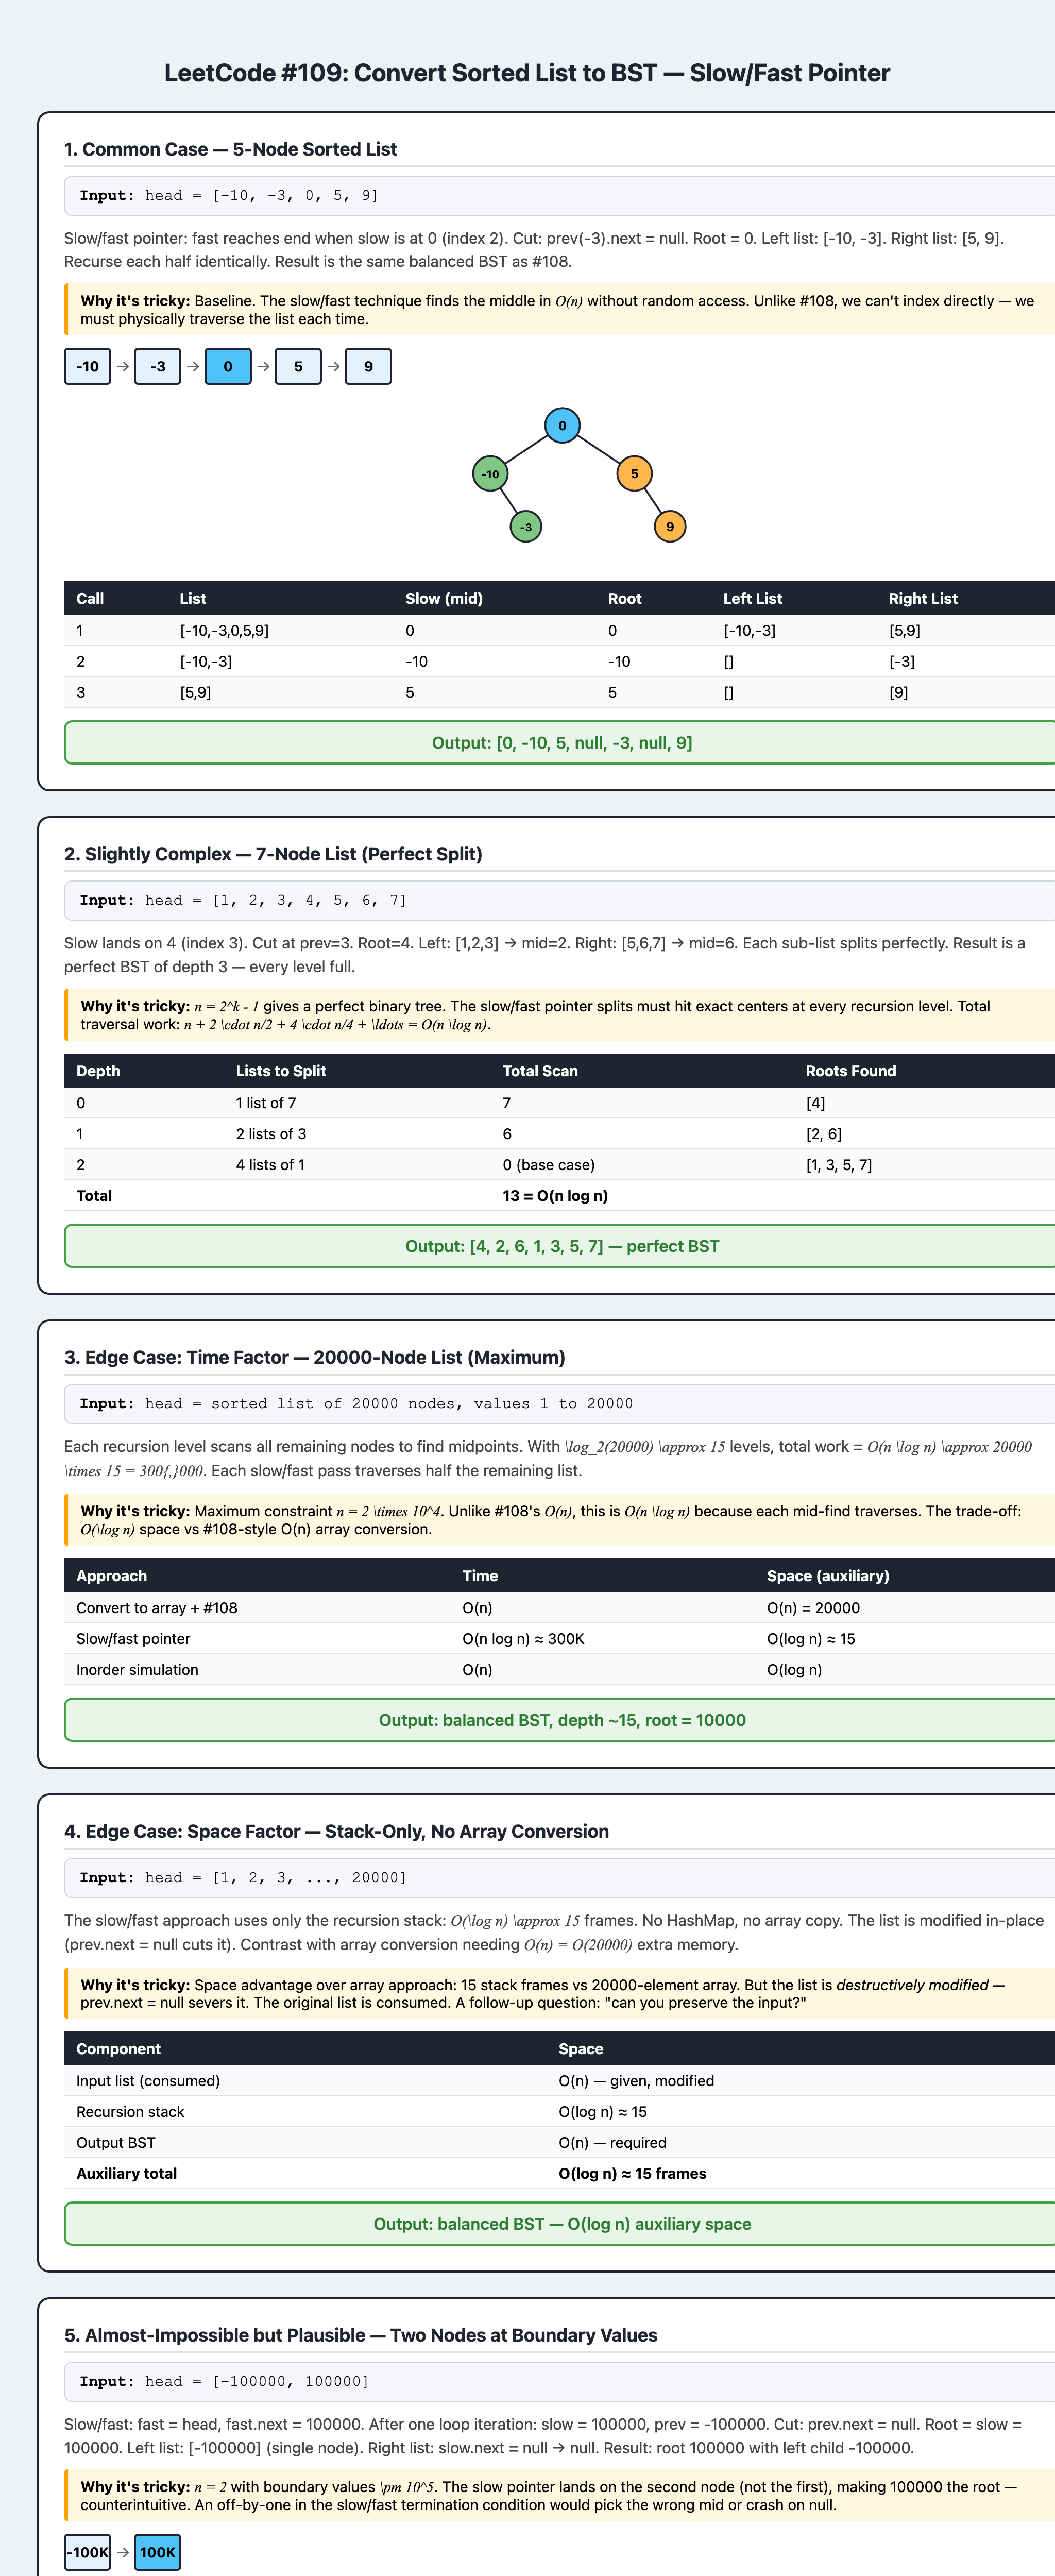